# Applications: QAOA for MaxCut

The Quantum Approximate Optimization Algorithm (QAOA) is used for solving combinatorial optimization problems.

Here we solve the MaxCut problem for a 3-node triangle graph. The objective is to partition the nodes to maximize the cut edges.

In [1]:
import numpy as np
from scipy.optimize import minimize
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

### 1. Cost Hamiltonian
Minimizing this Hamiltonian corresponds to maximizing the graph cut.

In [2]:
observable = SparsePauliOp.from_list([
    ("ZZI", 0.5), 
    ("IZZ", 0.5), 
    ("ZIZ", 0.5)
])
print(observable)

SparsePauliOp(['ZZI', 'IZZ', 'ZIZ'],
              coeffs=[0.5+0.j, 0.5+0.j, 0.5+0.j])


### 2. QAOA Ansatz

QAOA Ansatz parameters: 4


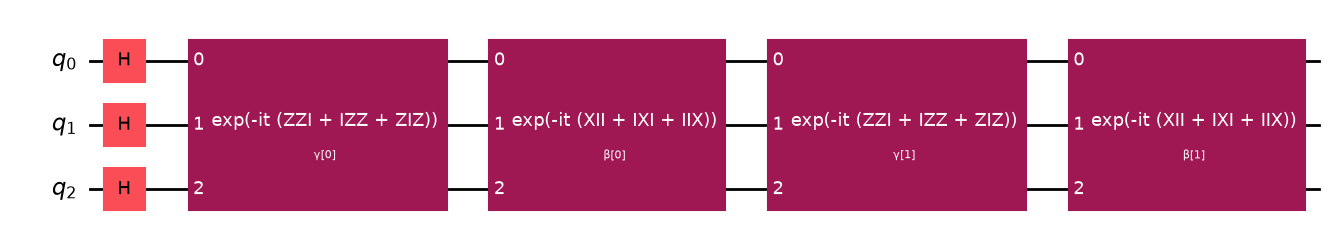

In [3]:
qaoa = QAOAAnsatz(cost_operator=observable, reps=2)
print(f"QAOA Ansatz parameters: {qaoa.num_parameters}")
qaoa.decompose().draw('mpl')

### 3. Optimization

In [4]:
estimator = StatevectorEstimator()

def qaoa_cost(params):
    pub = (qaoa, observable, params)
    return estimator.run([pub]).result()[0].data.evs

initial_params = np.random.uniform(-np.pi, np.pi, qaoa.num_parameters)
res = minimize(qaoa_cost, initial_params, method="COBYLA", options={"maxiter": 100})

print(f"Optimal Cost Value: {res.fun:.4f}")
print(f"Optimal Parameters: {res.x}")

/home/paolo/Dev/variational-algorithm-design/.venv/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/paolo/Dev/variational-algorithm-design/.venv/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


Optimal Cost Value: -0.5000
Optimal Parameters: [ 2.88109401 -0.36994661 -1.71344308 -1.34881   ]
